In [184]:
from astropy.io import fits
from astropy import units as u
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from astropy.visualization import quantity_support
quantity_support()

sdss_general_path = "C:/Users/lrik/Work"
sdss_filename_fits = "specObj-dr17.fits"
sdss_path = f"{sdss_general_path}/{sdss_filename_fits}"

spec_path = "C:/Users/lrik/Work/spectra"

from specutils import SpectralRegion

In [2]:
fix_number = lambda x: ('0000' + str(x))[-4:] if len(str(x)) < 5 else str(x)
file_path = lambda i, x: f"{spec_path}/{x.loc[i,'RUN2D']}/{fix_number(x.loc[i,'PLATE'])}/spec-{fix_number(x.loc[i,'PLATE'])}-{x.loc[i,'MJD']}-{fix_number(x.loc[i,'FIBERID'])}.fits"
file_name = lambda i, x: f"spec-{fix_number(x.loc[i,'PLATE'])}-{x.loc[i,'MJD']}-{fix_number(x.loc[i,'FIBERID'])}"

In [318]:
O_II = SpectralRegion(3717 * u.AA, 3737 * u.AA)
H_B = SpectralRegion(4851 * u.AA, 4871 * u.AA)
O_III_1 = SpectralRegion(4353 * u.AA, 4373 * u.AA)
O_III_21 = SpectralRegion(4949 * u.AA, 4969 * u.AA)
O_III_22 = SpectralRegion(4997 * u.AA, 5017 * u.AA)
H_A = SpectralRegion(6553 * u.AA, 6573 * u.AA)
N_II_1 = SpectralRegion(6538 * u.AA, 6558 * u.AA)
N_II_2 = SpectralRegion(6574 * u.AA, 6594 * u.AA)
S_II_1 = SpectralRegion(6707 * u.AA, 6727 * u.AA)
S_II_2 = SpectralRegion(6721 * u.AA, 6741 * u.AA)
HE_I = SpectralRegion(5866 * u.AA, 5886 * u.AA)

NE_III = SpectralRegion(3859 * u.AA, 3879 * u.AA)
H_D = SpectralRegion(4092 * u.AA, 4112 * u.AA)
H_G = SpectralRegion(4330 * u.AA, 4350 * u.AA)
HE_II = SpectralRegion(4676 * u.AA, 4696 * u.AA)
O_I = SpectralRegion(6290 * u.AA, 6310 * u.AA)
AR_III = SpectralRegion(7125 * u.AA, 7145 * u.AA)
O_II_1 = SpectralRegion(7310 * u.AA, 7330 * u.AA)
O_II_2 = SpectralRegion(7320 * u.AA, 7340 * u.AA)

CA_II_K = SpectralRegion(3923.7 * u.AA, 3943.7 * u.AA)
CA_II_H = SpectralRegion(3958.5 * u.AA, 3978.5 * u.AA)

MG_B = SpectralRegion(5165 * u.AA, 5185 * u.AA) #тріплет
FE_1 = SpectralRegion(5260 * u.AA, 5280 * u.AA)
FE_2 = SpectralRegion(5325 * u.AA, 5345 * u.AA)

lines_name = ['O_II', 'H_B', 'O_III_1', 'O_III_21', 'O_III_22', 'H_A', 'N_II_1', 'N_II_2', 'S_II_1', 'S_II_2', 'HE_I',
              'NE_III', 'H_D', 'H_G', 'HE_II', 'O_I', 'AR_III', 'O_II_1', 'O_II_2', 'CA_II_K', 'CA_II_H', 'MG_B', 'FE_1', 'FE_2']
lines_range = [O_II, H_B, O_III_1, O_III_21, O_III_22, H_A, N_II_1, N_II_2, S_II_1, S_II_2, HE_I,
               NE_III, H_D, H_G, HE_II, O_I, AR_III, O_II_1, O_II_2, CA_II_K, CA_II_H, MG_B, FE_1, FE_2]

In [ ]:
#data = pd.read_csv(f"{sdss_general_path}/SDSS_spec_wi.csv", dtype=str, keep_default_na=False,
#                   nrows=10)
data = pd.read_csv(f"{sdss_general_path}/SDSS_spec_SFG_SBG.csv", 
                     dtype={'SPECOBJID': str, 'FLUXOBJID': str, 'BESTOBJID': str, 'PLATEID': str}, 
                     keep_default_na=False)
data

In [140]:
j = 300
name = file_name(j,data)
spect = fits.open(file_path(j,data))
specdata = spect[1].data

In [240]:
from specutils import Spectrum
#redshift
wave = 10**specdata['loglam'] * u.AA / (1 + data.loc[j,'z'])
flux = specdata['flux'] * u.Unit('1e-17 erg cm-2 s-1 AA-1')

from astropy.nddata import InverseVariance

uncertainty = InverseVariance(specdata['ivar'])

spec = Spectrum(spectral_axis=wave, flux=flux, uncertainty=uncertainty)

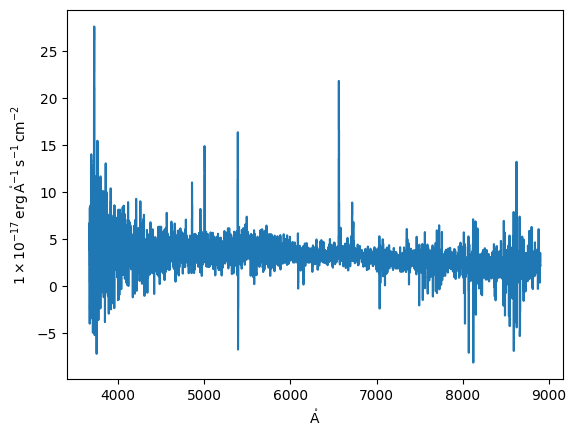

In [241]:
f, ax = plt.subplots()
ax.step(spec.spectral_axis, spec.flux)

In [168]:
specdata['and_mask'],specdata['or_mask']

(array([0, 0, 0, ..., 4, 4, 4]), array([0, 0, 0, ..., 4, 4, 4]))

Професійною практикою вважається встановлення ivar = 0 для всіх точок, де and_mask != 0, перед початком аналізу.

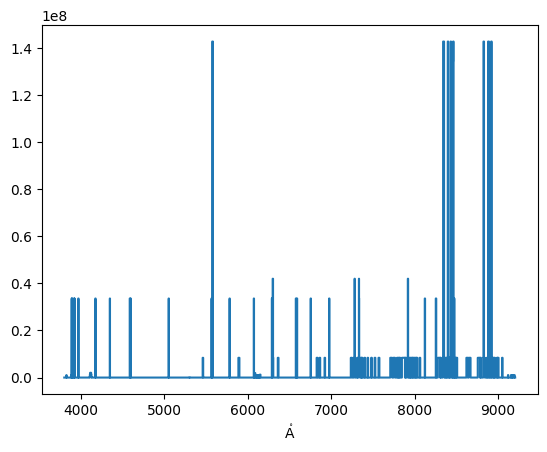

In [169]:
f, ax = plt.subplots()
ax.step(spec.spectral_axis, specdata['or_mask'])

In [306]:
import warnings

from specutils.fitting import fit_generic_continuum, fit_continuum

from specutils.analysis import snr
from specutils.analysis import line_flux
from specutils.analysis import centroid
from specutils.analysis import gaussian_sigma_width, gaussian_fwhm, fwhm, fwzi
from specutils.analysis import equivalent_width

def spec_line_info(spec, spec_region):
    
    with warnings.catch_warnings():  # Ignore warnings
        warnings.simplefilter('ignore')
        cont_norm_spec = spec / fit_generic_continuum(spec)(spec.spectral_axis)
        subtracted_spec = spec - fit_continuum(spec)(spec.wavelength)

    snr_ = snr(spec, region=spec_region)

    line_flux_ = line_flux(subtracted_spec, regions=spec_region)

    centroid_ = centroid(subtracted_spec, regions=spec_region)

    gaussian_sigma_width_ = gaussian_sigma_width(spec,regions=spec_region)
    gaussian_fwhm_ = gaussian_fwhm(spec,regions=spec_region)
    fwhm_ = fwhm(spec,regions=spec_region)
    fwzi_ = fwzi(subtracted_spec,regions=spec_region)

    equivalent_width_ = equivalent_width(cont_norm_spec, regions=spec_region)

    columns = ['snr', 'line_flux', 'centroid', 'gaussian_sigma_width',
            'gaussian_fwhm', 'fwhm', 'fwzi', 'equivalent_width']

#    return pd.DataFrame([[snr_.value, line_flux_.value, centroid_.value, gaussian_sigma_width_.value,
#                gaussian_fwhm_.value, fwhm_.value, fwzi_.value, equivalent_width_.value]],columns=columns)

    return pd.DataFrame(list(map(list, zip(*[snr_, line_flux_, centroid_, gaussian_sigma_width_,
                gaussian_fwhm_, fwhm_, fwzi_, equivalent_width_]))),columns=columns)

In [319]:
df = spec_line_info(spec,lines_range)
df.index = lines_name

INFO: the associated NDData object was deleted and cannot be accessed anymore. You can prevent the NDData object from being deleted by assigning it to a variable. If this happened after unpickling make sure you pickle the parent not the uncertainty directly. [astropy.nddata.nduncertainty]


c:\Users\lrik\AppData\Local\Programs\Python\Python310\lib\site-packages\astropy\nddata\nduncertainty.py:1221: RuntimeWarning: divide by zero encountered in divide
  new_array = None if self.array is None else 1 / self.array


In [320]:
df

,snr,line_flux,centroid,gaussian_sigma_width,gaussian_fwhm,fwhm,fwzi,equivalent_width
O_II,2.1773712635040283,112.71615033501043 1e-17 erg / (s cm2),3728.737372063194 Angstrom,3.950739622116089 Angstrom,9.303280854856965 Angstrom,4.9466296096325095 Angstrom,11.99999897123925 Angstrom,-29.85908649909653 Angstrom
H_B,3.9073474407196045,11.49907692528736 1e-17 erg / (s cm2),4868.398120369392 Angstrom,5.246192455291748 Angstrom,12.35383915381114 Angstrom,3.860299071047848 Angstrom,5.999995218830616 Angstrom,-3.124154211150025 Angstrom
O_III_1,1.9180119037628174,-17.13134099360687 1e-17 erg / (s cm2),4361.181002622169 Angstrom,5.243961334228516 Angstrom,12.34858526520855 Angstrom,8.711556036429101 Angstrom,1.9999997999999994 Angstrom,4.388498583288225 Angstrom
O_III_21,3.9996509552001953,9.21701658417614 1e-17 erg / (s cm2),4961.918149944907 Angstrom,5.3960700035095215 Angstrom,12.706773808654447 Angstrom,6.017218988701643 Angstrom,6.999997247651943 Angstrom,-2.523082026920304 Angstrom
O_III_22,5.5543532371521,40.453577978508534 1e-17 erg / (s cm2),5008.158965187675 Angstrom,4.716341018676758 Angstrom,11.106134369981715 Angstrom,4.116965711579724 Angstrom,6.999998497120218 Angstrom,-10.850283691108226 Angstrom
H_A,10.995065689086914,76.87719016717153 1e-17 erg / (s cm2),6564.503385767064 Angstrom,4.156558990478516 Angstrom,9.787948429132415 Angstrom,4.607700015293631 Angstrom,7.9999947550549955 Angstrom,-23.56464108777435 Angstrom
N_II_1,6.473609924316406,3.923822627210627 1e-17 erg / (s cm2),6550.46555069708 Angstrom,5.676079273223877 Angstrom,13.366145249772288 Angstrom,18.09130859375 Angstrom,5.999999162890926 Angstrom,-1.2314779616916374 Angstrom
N_II_2,6.761316776275635,9.57365286039237 1e-17 erg / (s cm2),6588.774919778496 Angstrom,5.125260829925537 Angstrom,12.069066938320614 Angstrom,9.384680805532298 Angstrom,6.999993803167744 Angstrom,-2.9714239542770784 Angstrom
S_II_1,6.832797527313232,24.323746784191602 1e-17 erg / (s cm2),6716.644270799072 Angstrom,5.372082233428955 Angstrom,12.650286926833134 Angstrom,4.439037921619274 Angstrom,5.999999044325882 Angstrom,-7.631418021618459 Angstrom
S_II_2,7.052700996398926,19.466658453607295 1e-17 erg / (s cm2),6733.295953526616 Angstrom,5.276966094970703 Angstrom,12.426305537385703 Angstrom,15.867029594347514 Angstrom,7.832466146334543 Angstrom,-6.126576011679863 Angstrom


In [254]:
spec_at_rest = spec

C:\Users\lrik\AppData\Local\Temp\ipykernel_19068\3235382492.py:7: RuntimeWarning: divide by zero encountered in power
  sigma = spec_at_rest.uncertainty.array**-0.5


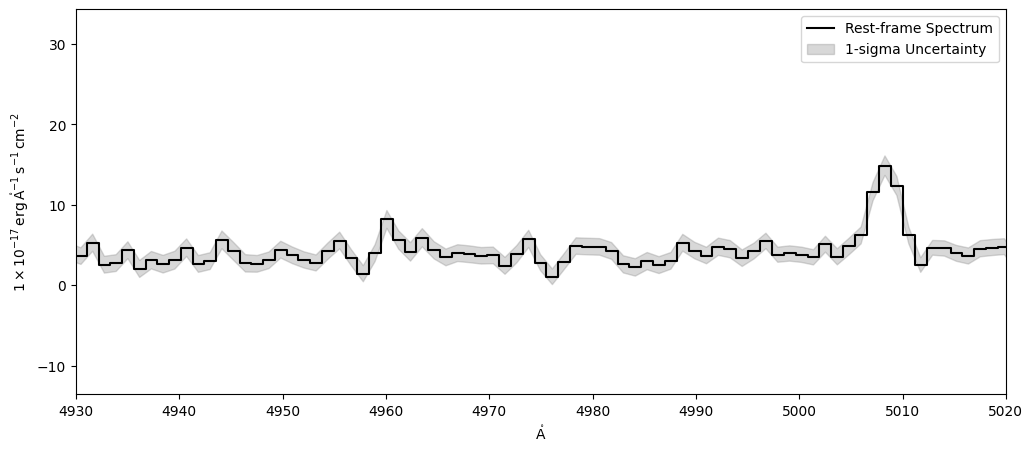

In [258]:
plt.figure(figsize=(12, 5))
# Малюємо основний спектр
plt.step(spec_at_rest.spectral_axis, spec_at_rest.flux, where='mid', color='black', label='Rest-frame Spectrum')

# Малюємо похибку (1-sigma) як напівпрозору область
# Пам'ятайте, що в SDSS ми витягли ivar, тому sigma = 1/sqrt(ivar)
sigma = spec_at_rest.uncertainty.array**-0.5
plt.fill_between(spec_at_rest.spectral_axis.value, 
                 spec_at_rest.flux.value - sigma, 
                 spec_at_rest.flux.value + sigma, 
                 color='gray', alpha=0.3, label='1-sigma Uncertainty')

plt.xlim(4930, 5020) # Фокусуємося на головних лініях Ca II та Mg b
plt.legend()
plt.show()

<h2> Dereddening </h2>

In [ ]:
from dust_extinction.parameter_averages import F99
ext = F99(Rv = 3.1)

In [ ]:
ra = data['RA']
dec = data['DEC']

from dustmaps.config import config
config['data_dir'] = ""
from astropy.coordinates import SkyCoord
from astropy import units as u
from dustmaps.sfd import SFDQuery
coords = SkyCoord(ra=ra, dec=dec, unit=(u.degree,u.degree))
del ra, dec
coords.galactic
sfd = SFDQuery()
ebv = sfd(coords)
del coords

In [ ]:
flux_ext = spec.flux * ext.extinguish(spec.spectral_axis, Ebv=ebv)
spec_ext = Spectrum(spectral_axis=wave, flux=flux_ext)

<h1> Normalization </h1>

Very complicated

In [172]:
fit_generic_continuum(spec,model=pol.Chebyshev1D(3, c0=0., c1=1., c2=1., c3=1.))(spec.spectral_axis)

<Quantity [3.78630551, 3.78641417, 3.78652292, ..., 1.89297552, 1.89153054,
           1.89008391] 1e-17 erg / (Angstrom s cm2)>

In [211]:
import warnings
from specutils.fitting import fit_generic_continuum
import astropy.modeling.polynomial as pol

with warnings.catch_warnings():  # Ignore warnings
    warnings.simplefilter('ignore')
    cont_norm_spec = spec / fit_generic_continuum(spec)(spec.spectral_axis)

INFO: the associated NDData object was deleted and cannot be accessed anymore. You can prevent the NDData object from being deleted by assigning it to a variable. If this happened after unpickling make sure you pickle the parent not the uncertainty directly. [astropy.nddata.nduncertainty]


In [210]:
from specutils.fitting.continuum import fit_continuum
fit_continuum(spec), fit_generic_continuum(spec)

INFO: the associated NDData object was deleted and cannot be accessed anymore. You can prevent the NDData object from being deleted by assigning it to a variable. If this happened after unpickling make sure you pickle the parent not the uncertainty directly. [astropy.nddata.nduncertainty]


(<QuantityModel Chebyshev1D(3, c0=1.64843643, c1=0.00108661, c2=-0.00000008, c3=0.), input_units=Angstrom, return_units=1e-17 erg / (Angstrom s cm2)>,
 <QuantityModel Chebyshev1D(3, c0=1.39062397, c1=0.00120677, c2=-0.00000009, c3=0.), input_units=Angstrom, return_units=1e-17 erg / (Angstrom s cm2)>)

INFO: the associated NDData object was deleted and cannot be accessed anymore. You can prevent the NDData object from being deleted by assigning it to a variable. If this happened after unpickling make sure you pickle the parent not the uncertainty directly. [astropy.nddata.nduncertainty]


(3.75, 3.8)

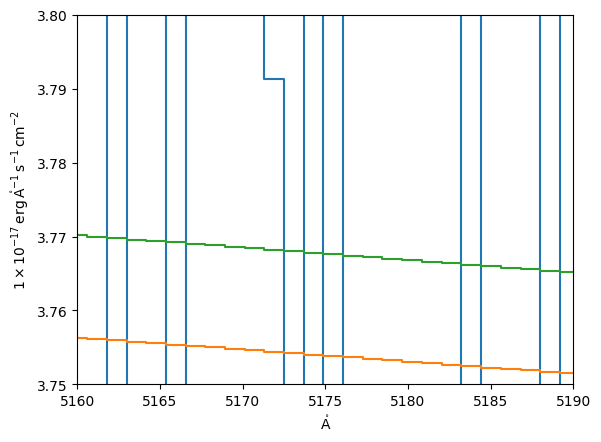

In [208]:
f, ax = plt.subplots()
ax.step(spec.wavelength, spec.flux)
ax.step(spec.wavelength, fit_generic_continuum(spec,model=pol.Chebyshev1D(3, c0=0., c1=1., c2=1., c3=1.))(spec.spectral_axis))
ax.step(spec.wavelength, fit_continuum(spec)(spec.wavelength))
#ax.step(spec.wavelength, fit_generic_continuum(spec,model=m)(spec.spectral_axis))
ax.set_xlim(516 * u.nm, 519 * u.nm)
ax.set_ylim(3.75,3.8)


Median

In [89]:
np.median(spec.flux)

<Quantity 3.2466118e-17 erg / (Angstrom s cm2)>

In [102]:
cont_norm_spec = spec / np.median(spec.flux)

<h2> the equivalent width of a spectral line </h2>

In [213]:
from specutils.analysis import equivalent_width
equivalent_width(cont_norm_spec, regions=SpectralRegion(5160 * u.AA, 5190 * u.AA))

<Quantity -13.02295559 Angstrom>

(5159.999999999999, 5189.999999999999)

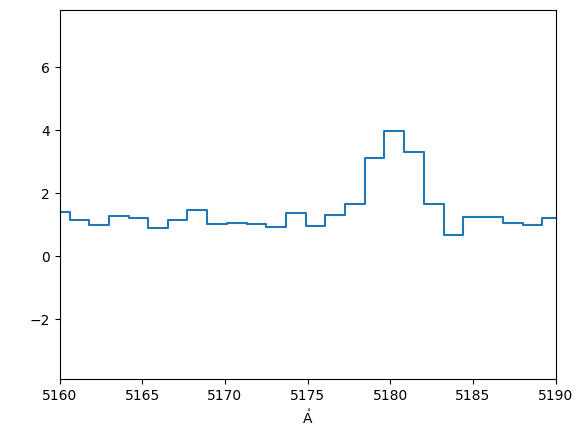

In [216]:
f, ax = plt.subplots()
ax.step(cont_norm_spec.wavelength, cont_norm_spec.flux)
#ax.step(spec.spectral_axis, spec.flux.value)
ax.set_xlim(516 * u.nm, 519 * u.nm)